## Linear Regressoion

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.linear_regression import LinearRegression

$$ Y=2X + \epsilon $$
Where $\epsilon$ is a random noise.

Error:  0.6282705049960303


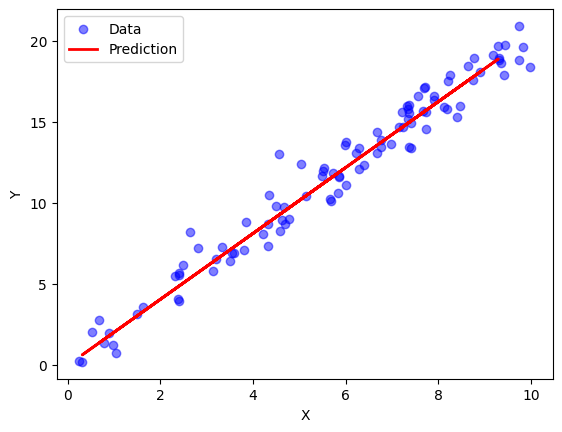

In [2]:
from sklearn.model_selection import train_test_split

X=np.random.rand(100,1)*10
Y=2*X+np.random.randn(100,1)

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2)
model=LinearRegression()
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
error=np.mean((Y_pred-Y_test)**2)
print("Error: ",error)

plt.scatter(X,Y, color='blue', alpha=0.5, label='Data')
plt.plot(X_test, Y_pred, color='red', linewidth=2, label='Prediction')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## Feature Map
$$ \phi(X)=[1,X,X^2] $$

$$ Y=w^T\phi(X) + \epsilon $$

Error:  1.1151506537486815


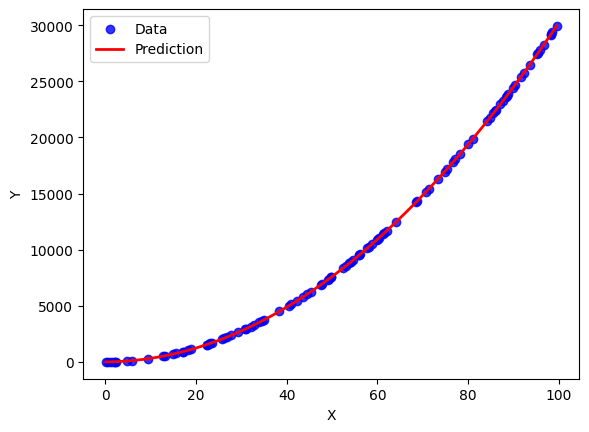

In [3]:
X=np.random.rand(100,1)*100
w=np.array([[1],[2],[3]])
phi_X=np.hstack((np.ones((100,1)),X,X**2))
Y=phi_X.dot(w)+np.random.randn(100,1)

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2)
features_map= lambda x: np.hstack((np.ones((x.shape[0],1)),x,x**2))
X_train_phi=features_map(X_train)
X_test_phi=features_map(X_test)
model=LinearRegression()
model.fit(X_train_phi,Y_train)
Y_pred=model.predict(X_test_phi)
error=np.mean((Y_pred-Y_test)**2)
print("Error: ",error)

X_plot = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
X_plot_phi = features_map(X_plot)
Y_plot = model.predict(X_plot_phi)

plt.scatter(X, Y, color='blue', alpha=0.8, label='Data')
plt.plot(X_plot, Y_plot, color='red', linewidth=2, label='Prediction')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## Scikit learn implementation

In [4]:
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.linear_model import Ridge as SklearnRidge
model=SklearnLinearRegression()
model.fit(X_train_phi,Y_train)
Y_pred=model.predict(X_test_phi)
error=np.mean((Y_pred-Y_test)**2)
print("Error: ",error)

Error:  1.115150653764932


## Logistic Regression

Accuracy:  0.9473684210526315
[[30  6]
 [ 0 78]]


<function matplotlib.pyplot.show(close=None, block=None)>

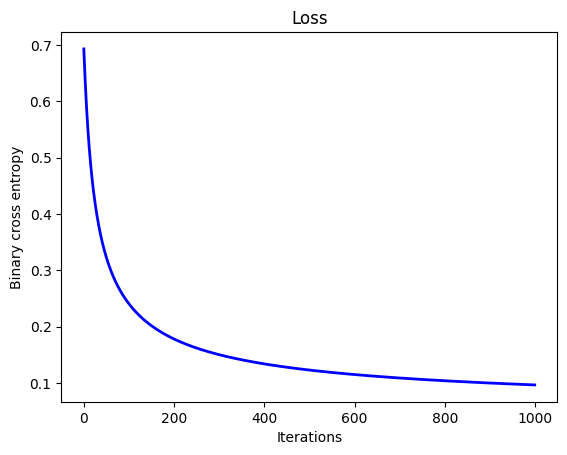

In [5]:
from src.logistic_regression import LogisticRegression
from src.standard_scaler import StandardScaler
from sklearn import datasets
from sklearn.metrics import confusion_matrix

dataset=datasets.load_breast_cancer()
X,Y= dataset.data, dataset.target
X_train, X_test, Y_train, Y_test=train_test_split(X,Y,test_size=0.2)
logr=LogisticRegression(learning_rate=0.01, n_iterations=1000)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train) 
X_test_scaled=scaler.transform(X_test)
logr.fit(X_train_scaled,Y_train)
Y_pred=logr.predict(X_test_scaled)
accuracy=np.mean(Y_pred==Y_test)
print("Accuracy: ",accuracy)

print(confusion_matrix(Y_test,Y_pred))

plt.plot(logr.losses,color='blue', linewidth=2)
plt.title("Loss")
plt.xlabel("Iterations")
plt.ylabel("Binary cross entropy")
plt.show